In [ ]:
!pip install datasets -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12=

In [ ]:
!pip install transformers -qq

In [ ]:
!pip install evaluate -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
from typing import List, Tuple

In [ ]:
from datasets import load_dataset, Dataset
import evaluate
import numpy as np
from sklearn.metrics import classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
from transformers import pipeline

# Языковые модели трансформеры

[Attention Is All You Need](https://arxiv.org/abs/1706.03762) – архетектура трансформера  
[BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805) – про BERT  
[Модели внимания и трансформеры](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%28%D0%BA%D1%83%D1%80%D1%81_%D0%BB%D0%B5%D0%BA%D1%86%D0%B8%D0%B9%2C_%D0%9A.%D0%92.%D0%92%D0%BE%D1%80%D0%BE%D0%BD%D1%86%D0%BE%D0%B2%29#.D0.9C.D0.BE.D0.B4.D0.B5.D0.BB.D0.B8_.D0.B2.D0.BD.D0.B8.D0.BC.D0.B0.D0.BD.D0.B8.D1.8F_.D0.B8_.D1.82.D1.80.D0.B0.D0.BD.D1.81.D1.84.D0.BE.D1.80.D0.BC.D0.B5.D1.80.D1.8B) – лекция Воронцова про трансформеры




**Запись лекции про трансформеры**  
https://www.youtube.com/watch?v=KhMweP00S44

## Механизм внимания

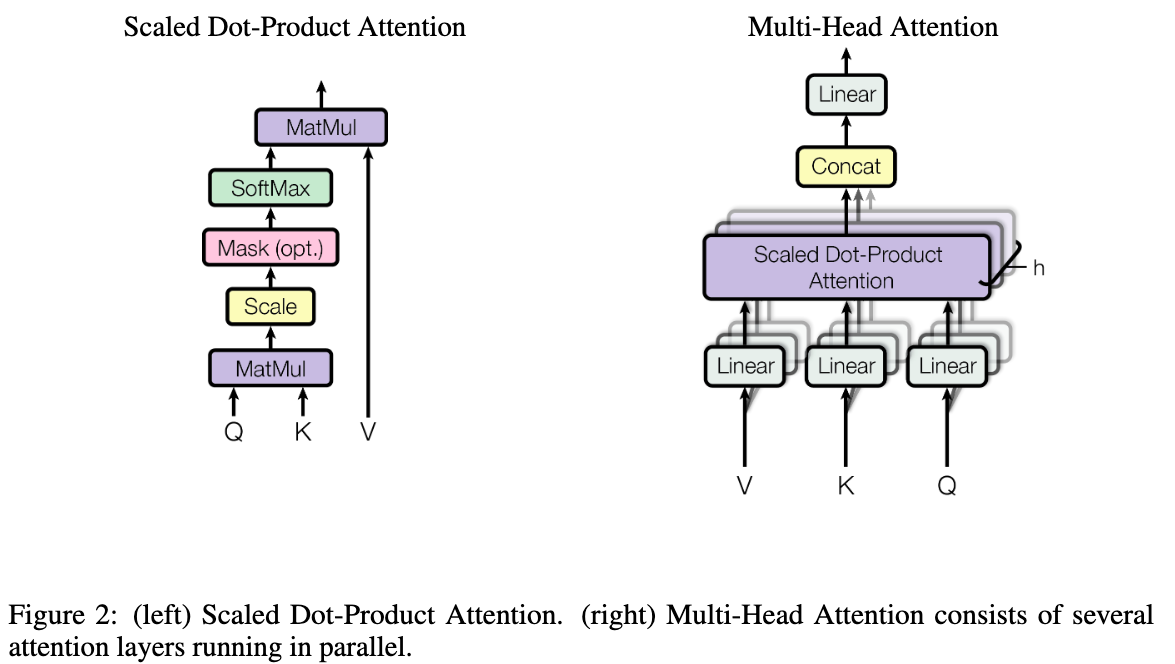

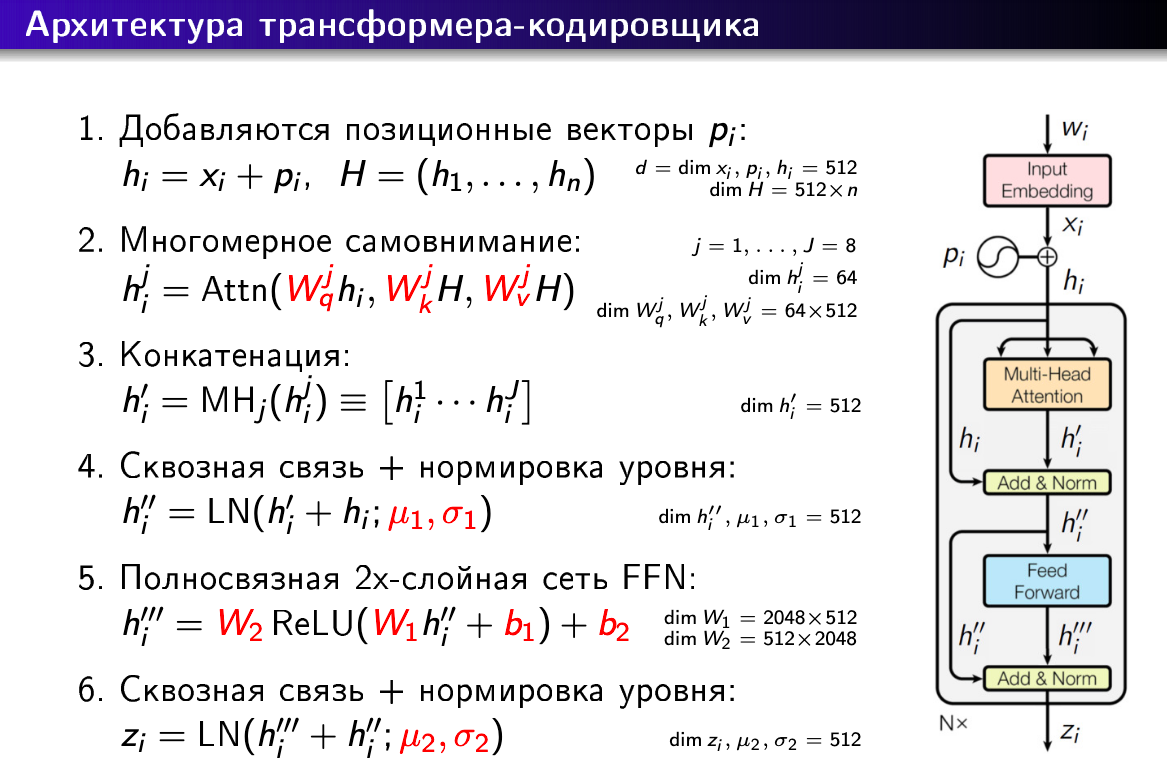

## Предварительное обучение BERT

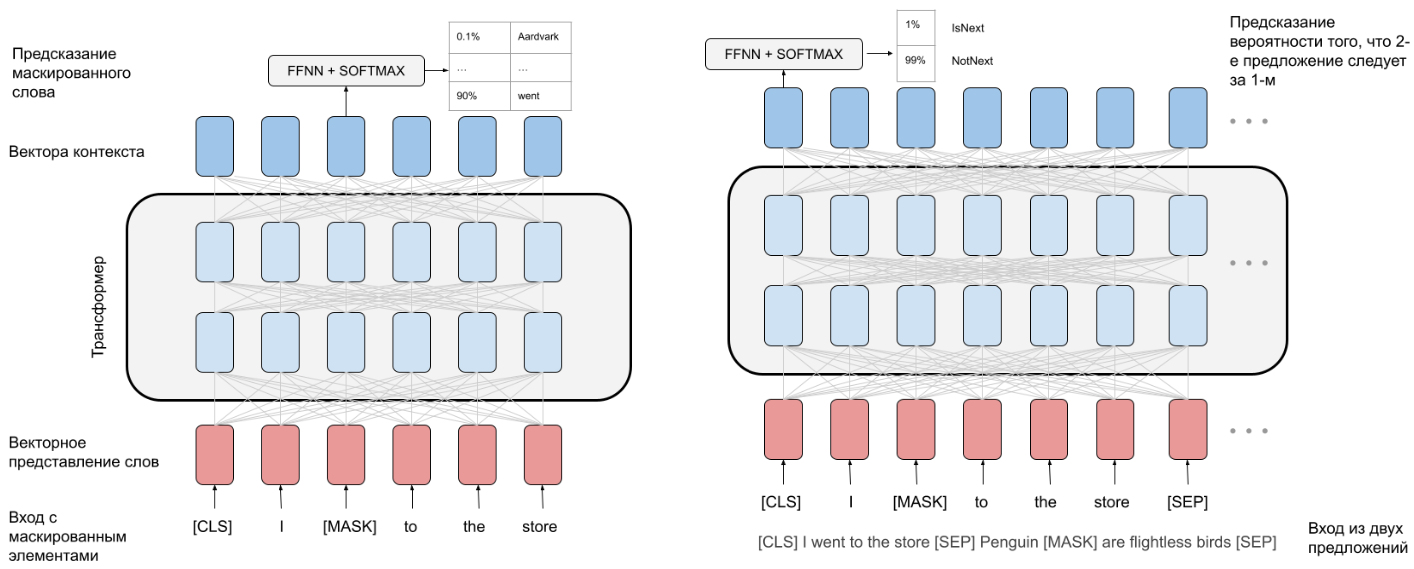

## BERT "понимает" грамматику и синтаксис языка

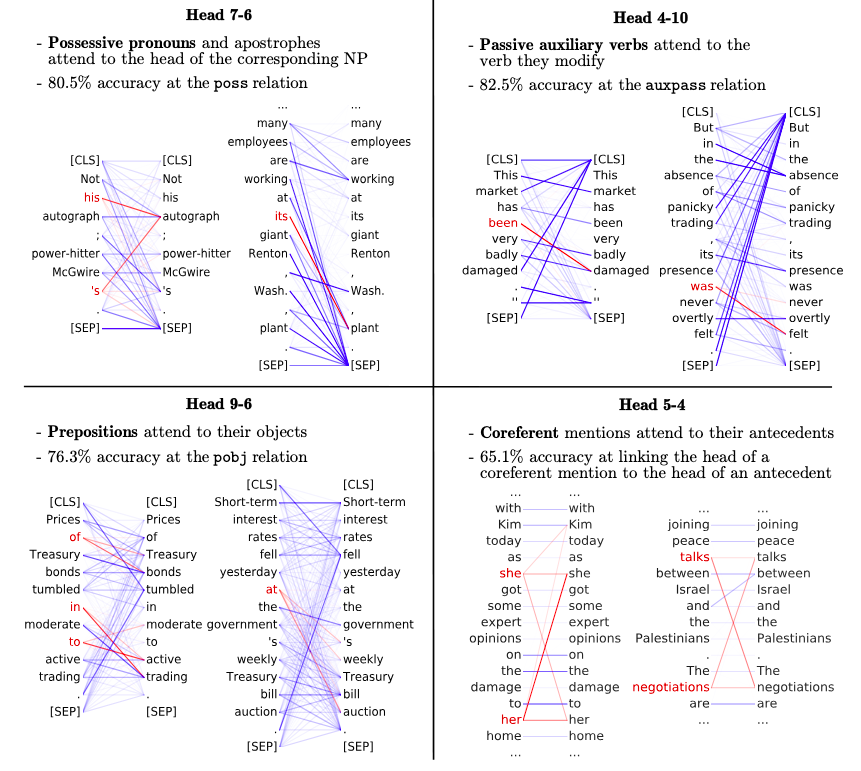

[What does BERT look at? An Analysis of BERT’s Attention / Clark et al. // 2019](https://aclanthology.org/W19-4828/)

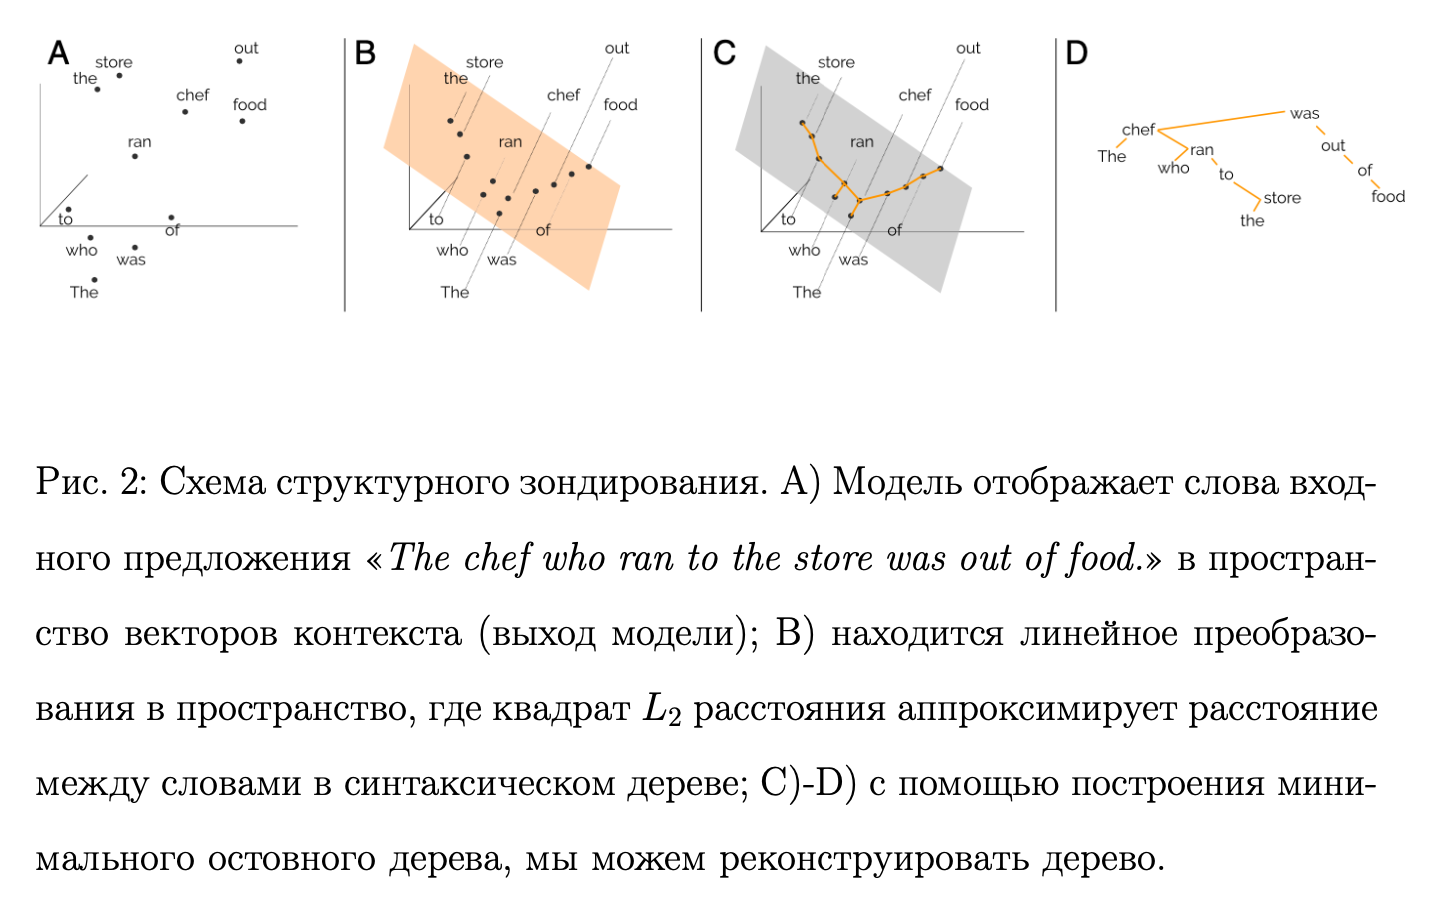

[A Structural Probe for Finding Syntax in Word Representations / Hewitt & Manning // 2019](https://aclanthology.org/N19-1419/)  
[Visualizing and Measuring the Geometry of BERT / Coenen et al. // 2019](https://arxiv.org/abs/1906.02715)

# Pipeline дообучения модели

In [ ]:
SEED = 42

## Загрузим токенайзер

In [ ]:
MODEL_NAME = 'DeepPavlov/rubert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
seq = 'Привет о дивный новый мир!'
print(tokenizer.encode(seq))
print(tokenizer.convert_ids_to_tokens(tokenizer.encode(seq)))

[101, 77527, 612, 32136, 1916, 10303, 6913, 106, 102]
['[CLS]', 'Привет', 'о', 'див', '##ный', 'новый', 'мир', '!', '[SEP]']


## Загрузим данные

In [ ]:
DATASET_NAME = 'Davlan/sib200'
DATASET_LANGUAGE = 'rus_Cyrl'
train_set = load_dataset(DATASET_NAME, DATASET_LANGUAGE, split='train')
validation_set = load_dataset(DATASET_NAME, DATASET_LANGUAGE, split='validation')
test_set = load_dataset(DATASET_NAME, DATASET_LANGUAGE, split='test')

README.md:   0%|          | 0.00/47.9k [00:00<?, ?B/s]

data/rus_Cyrl/train.tsv:   0%|          | 0.00/195k [00:00<?, ?B/s]

data/rus_Cyrl/dev.tsv:   0%|          | 0.00/25.3k [00:00<?, ?B/s]

data/rus_Cyrl/test.tsv:   0%|          | 0.00/57.4k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
print(train_set)

Dataset({
    features: ['index_id', 'category', 'text'],
    num_rows: 701
})


## Токенизируем тексты

In [ ]:
MINIBATCH_SIZE = 64
tokenized_train_set = train_set.map(
    lambda it: tokenizer(it['text'], truncation=True),
    batched=True, batch_size=MINIBATCH_SIZE
)
tokenized_validation_set = validation_set.map(
    lambda it: tokenizer(it['text'], truncation=True),
    batched=True, batch_size=MINIBATCH_SIZE
)

Map:   0%|          | 0/701 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/99 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_train_set)

Dataset({
    features: ['index_id', 'category', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 701
})


## Загрузим метрику для оценки качества модели на задаче классификации

In [ ]:
cls_metric = evaluate.load('f1')

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return cls_metric.compute(predictions=predictions, references=labels, average='macro')

## Создадим вспомогательный объект для трансформации данных в тензор

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Конвертируем категории в целевые метки

In [ ]:
list_of_categories = sorted(list(
    set(train_set['category']) | set(validation_set['category']) | set(test_set['category'])
))
indices_of_categories = list(range(len(list_of_categories)))
n_categories = len(list_of_categories)
print(f'Categories for classification are: {list_of_categories}')
id2label = dict(zip(indices_of_categories, list_of_categories))
label2id = dict(zip(list_of_categories, indices_of_categories))

Categories for classification are: ['entertainment', 'geography', 'health', 'politics', 'science/technology', 'sports', 'travel']


In [ ]:
labeled_train_set = tokenized_train_set.add_column(
    'label',
    [label2id[val] for val in tokenized_train_set['category']]
)
labeled_validation_set = tokenized_validation_set.add_column(
    'label',
    [label2id[val] for val in tokenized_validation_set['category']]
)

In [ ]:
print(labeled_train_set)

Dataset({
    features: ['index_id', 'category', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
    num_rows: 701
})


# TensorBoard

## Загружаем наш BERT
И определем его на видеокарту

In [ ]:
classifier = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_categories, id2label=id2label, label2id=label2id
).cuda()
for param in classifier.parameters(): param.data = param.data.contiguous()

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Этап обучения

In [ ]:
training_args = TrainingArguments(
    output_dir='rubert_sib200',
    learning_rate=2e-5,
    per_device_train_batch_size=MINIBATCH_SIZE,
    per_device_eval_batch_size=MINIBATCH_SIZE,
    num_train_epochs=20,
    weight_decay=1e-3,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps = 5,
    # "warmup_ratio": 1/10,
    # "lr_scheduler_type": "cosine",
    # fp16=(device.type != 'cpu'),
    data_seed=SEED,
)

NameError: name 'TrainingArguments' is not defined

In [ ]:
trainer = Trainer(
    model=classifier,
    args=training_args,
    train_dataset=labeled_train_set,
    eval_dataset=labeled_validation_set,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,1.845600,1.697977,0.205660
2,1.530200,1.331063,0.523679
3,1.174600,0.948457,0.802405
4,0.835900,0.732447,0.829606
5,0.465700,0.540530,0.830273
6,0.330700,0.512785,0.838518
7,0.214900,0.464985,0.851714
8,0.137100,0.473245,0.836830
9,0.099800,0.474545,0.845787
10,0.055000,0.516513,0.823740


TrainOutput(global_step=220, training_loss=0.35520805008709433, metrics={'train_runtime': 1266.7681, 'train_samples_per_second': 11.068, 'train_steps_per_second': 0.174, 'total_flos': 422725386983400.0, 'train_loss': 0.35520805008709433, 'epoch': 20.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.4649854302406311,
 'eval_f1': 0.8517142429185567,
 'eval_runtime': 0.5145,
 'eval_samples_per_second': 192.415,
 'eval_steps_per_second': 3.887,
 'epoch': 20.0}

##  Оценим качество на отложенной выборке

In [ ]:
classifiсation_pipeline = pipeline('text-classification', model=classifier, tokenizer=tokenizer, device=0)

In [ ]:
y_pred = list(map(lambda x: x['label'], classifiсation_pipeline(validation_set['text'])))
y_true = validation_set['category']
print(classification_report(y_true=y_true, y_pred=y_pred))

                    precision    recall  f1-score   support

     entertainment       1.00      0.56      0.71         9
         geography       0.78      0.88      0.82         8
            health       1.00      0.82      0.90        11
          politics       0.87      0.93      0.90        14
science/technology       0.96      0.96      0.96        25
            sports       1.00      0.92      0.96        12
            travel       0.64      0.80      0.71        20

          accuracy                           0.86        99
         macro avg       0.89      0.84      0.85        99
      weighted avg       0.88      0.86      0.86        99



In [ ]:
y_pred = list(map(lambda x: x['label'], classifiсation_pipeline(test_set['text'])))
y_true = test_set['category']
print(classification_report(y_true=y_true, y_pred=y_pred))

                    precision    recall  f1-score   support

     entertainment       0.90      0.47      0.62        19
         geography       0.89      1.00      0.94        17
            health       0.91      0.91      0.91        22
          politics       0.97      0.97      0.97        30
science/technology       0.90      0.92      0.91        51
            sports       0.92      0.92      0.92        25
            travel       0.87      1.00      0.93        40

          accuracy                           0.91       204
         macro avg       0.91      0.88      0.89       204
      weighted avg       0.91      0.91      0.90       204

